**CASO DE ESTUDIO**
Modelamiento del riesgo derivado de las operaciones del negocio de una FINTECH

Una FINTECH quiere estimar las perdidas asociadas con el riesgo derivado de los fallos tecnologicos en transacciones de sus clientes a traves de sus canales electronicos

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nxl= '/content/1. FallasTecnológicas.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
XDB.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Fallas Tecnológicas (Canales Electronicos),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas (Freq),Valor Generado Promedio (Millones),Descripción Evento
1,2009-01-01 00:00:00,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
2,2009-01-02 00:00:00,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
3,2009-01-03 00:00:00,70,9.976,5,0.4269,"Errores visuales menores, problemas de usabili..."
4,2009-01-04 00:00:00,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."


#1-Distribucion agregada de perdidas

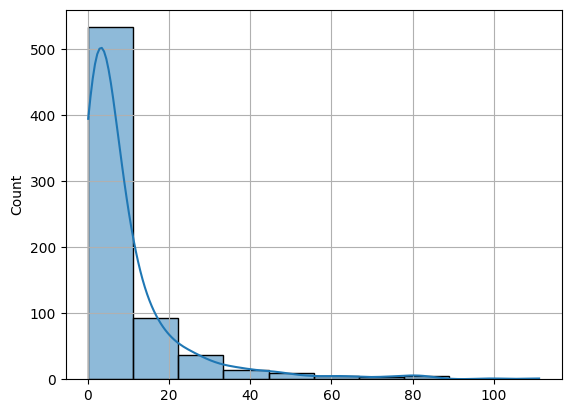

In [6]:
Freq=pd.to_numeric(XDB.iloc[1:,3])
Sev=pd.to_numeric(XDB.iloc[1:,4])
LDA=Freq*Sev

#Construccion de la distribucion agregada de las perdidas
plt.figure() #grafica
sns.histplot(LDA,bins=10,kde=True)
plt.grid()
plt.show()

#2-Clusterizacion estadistica definida por el histograma de frecuencias.Calculo de metricas estadisticas de tendencia central y dispersion: Media, Desviacion, Asimetria y Kurtosis

In [8]:
# Asegurar que LDA esté definido calculándolo nuevamente de XDB
Freq = pd.to_numeric(XDB.iloc[1:, 3], errors='coerce').fillna(0)
Sev = pd.to_numeric(XDB.iloc[1:, 4], errors='coerce').fillna(0)
LDA = Freq * Sev

u = np.mean(LDA)
varianza = np.var(LDA)
sigma = np.std(LDA)

Tabla2 = np.column_stack((u, varianza, sigma))
DataFrame2 = pd.DataFrame(Tabla2, columns=['Media', 'Varianza', 'Desviacion'])

from scipy.stats import skew, kurtosis

# Calcular asimetría
Ida_skew = skew(LDA)

# Calcular kurtosis
Ida_kurt = kurtosis(LDA)

# Añadir al data frame las métricas faltantes
DataFrame2['Asimetria'] = Ida_skew
DataFrame2['Kurtosis'] = Ida_kurt
display(DataFrame2)

,Media,Varianza,Desviacion,Asimetria,Kurtosis
0,9.451113,187.894776,13.707472,3.34836,14.167714


Los indicadores estadísticos evidencian que la distribución de las pérdidas no es simétrica y presenta una concentración significativa en valores inferiores al promedio, lo cual se confirma por el coeficiente de asimetría positivo (3,35). Esto indica que la mayoría de los eventos corresponden a pérdidas de menor magnitud, mientras que los eventos de pérdidas elevadas son menos frecuentes, pero influyen en el incremento de la media. Asimismo, el alto valor de la curtosis (14,17) sugiere que los datos están muy concentrados alrededor de ciertos valores y que existen algunos casos extremos poco frecuentes. En conjunto, estos resultados reflejan un comportamiento donde predominan pérdidas moderadas, con variaciones limitadas en la mayoría de los casos y algunos eventos aislados que aumentan la variabilidad total.